In [ ]:
import pandas as pd   
df = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/cleaned/satcat_cleaned.parquet")
df.head()

,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,...,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER
0,1957-001A,1,ROCKET BODY,SL-1 R/B,CIS,1957-10-04,TTMTR,1957-12-01,96.19,65.10,...,0,LARGE,1,1957,1,A,Y,SL-1 R/B,1957-001A,1
1,1957-001B,2,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,TTMTR,1958-01-03,96.10,65.00,...,0,None,7179,1957,1,B,Y,SPUTNIK 1,1957-001B,2
2,1957-002A,3,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,TTMTR,1958-04-14,103.74,65.33,...,0,SMALL,9221,1957,2,A,Y,SPUTNIK 2,1957-002A,3
3,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,...,0,None,1,1958,1,A,Y,EXPLORER 1,1958-001A,4
4,1958-002B,5,PAYLOAD,VANGUARD 1,US,1958-03-17,AFETR,None,132.60,34.26,...,0,SMALL,9385,1958,2,B,Y,VANGUARD 1,1958-002B,5


In [2]:
print(df.columns.tolist())

['INTLDES', 'NORAD_CAT_ID', 'OBJECT_TYPE', 'SATNAME', 'COUNTRY', 'LAUNCH', 'SITE', 'DECAY', 'PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE', 'COMMENT', 'COMMENTCODE', 'RCSVALUE', 'RCS_SIZE', 'FILE', 'LAUNCH_YEAR', 'LAUNCH_NUM', 'LAUNCH_PIECE', 'CURRENT', 'OBJECT_NAME', 'OBJECT_ID', 'OBJECT_NUMBER']


In [35]:
df['APOGEE'] = pd.to_numeric(df['APOGEE'], errors='coerce')
df['PERIGEE'] = pd.to_numeric(df['PERIGEE'], errors='coerce')
df['INCLINATION'] = pd.to_numeric(df['INCLINATION'], errors='coerce')
df['PERIOD'] = pd.to_numeric(df['PERIOD'], errors='coerce')
df['LAUNCH_YEAR'] = pd.to_numeric(df['LAUNCH_YEAR'], errors='coerce')

In [37]:
def classify_orbit(apogee):
    if pd.isna(apogee):
        return "UNKNOWN"
    if apogee < 2000:
        return "LEO"
    elif apogee < 35786:
        return "MEO"
    elif 35286 <= apogee <= 36286:
        return "GEO"
    else:
        return "HEO"

In [38]:
df['ORBIT_CLASS'] = df['APOGEE'].apply(classify_orbit)


In [39]:
df.head()

,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,...,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER,ORBIT_CLASS
0,1957-001A,1,ROCKET BODY,SL-1 R/B,CIS,1957-10-04,TTMTR,1957-12-01,96.19,65.10,...,LARGE,1,1957,1,A,Y,SL-1 R/B,1957-001A,1,LEO
1,1957-001B,2,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,TTMTR,1958-01-03,96.10,65.00,...,None,7179,1957,1,B,Y,SPUTNIK 1,1957-001B,2,LEO
2,1957-002A,3,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,TTMTR,1958-04-14,103.74,65.33,...,SMALL,9221,1957,2,A,Y,SPUTNIK 2,1957-002A,3,LEO
3,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,...,None,1,1958,1,A,Y,EXPLORER 1,1958-001A,4,LEO
4,1958-002B,5,PAYLOAD,VANGUARD 1,US,1958-03-17,AFETR,None,132.60,34.26,...,SMALL,9385,1958,2,B,Y,VANGUARD 1,1958-002B,5,MEO


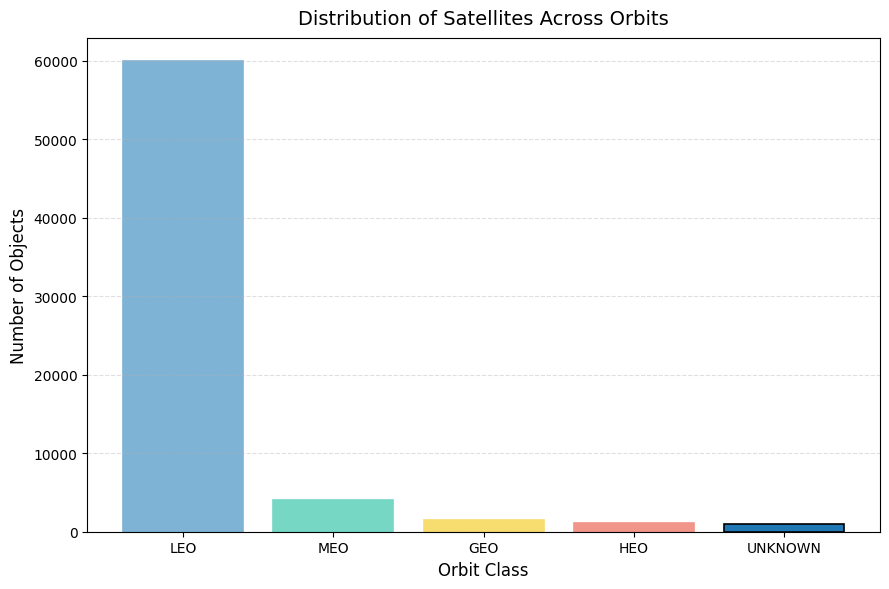

In [40]:
import matplotlib.pyplot as plt

orbit_counts = df['ORBIT_CLASS'].value_counts()

plt.figure(figsize=(9,6))
bars = plt.bar(orbit_counts.index, orbit_counts.values, edgecolor='black', linewidth=1.2)

# soft colors manually chosen
colors = ["#7FB3D5", "#76D7C4", "#F7DC6F", "#F1948A"]
for bar, c in zip(bars, colors):
    bar.set_color(c)

plt.title("Distribution of Satellites Across Orbits", fontsize=14, pad=10)
plt.xlabel("Orbit Class", fontsize=12)
plt.ylabel("Number of Objects", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

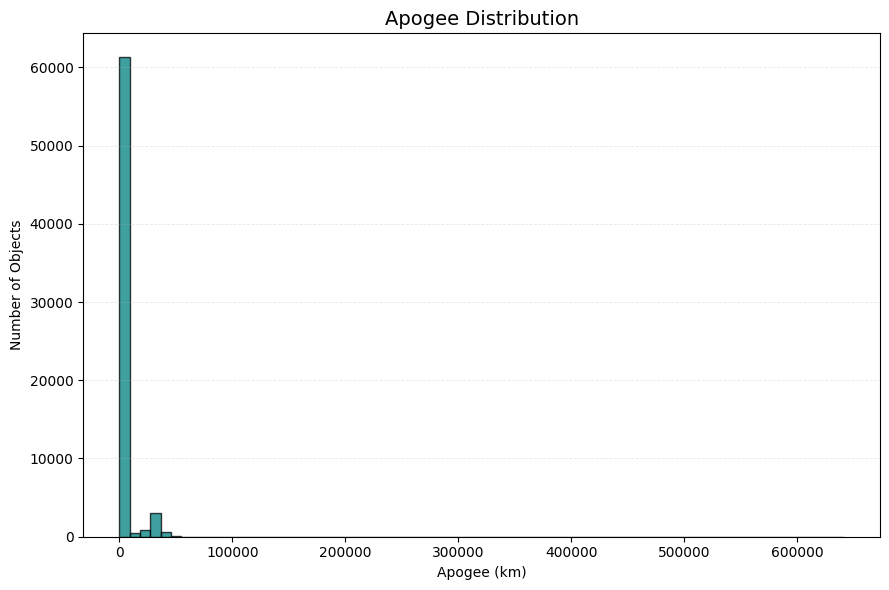

In [41]:
plt.figure(figsize=(9,6))
plt.hist(
    df['APOGEE'].dropna(),
    bins=70,
    color="teal",
    edgecolor="black",
    alpha=0.75
)

plt.xlabel("Apogee (km)")
plt.ylabel("Number of Objects")
plt.title("Apogee Distribution", fontsize=14)

plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.3)
plt.tight_layout()
plt.show()

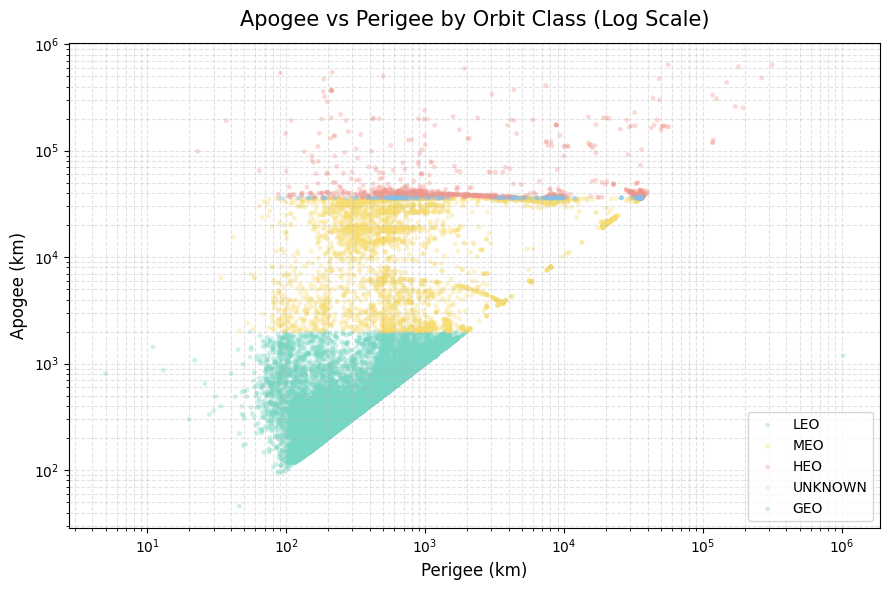

In [42]:
colors = {"LEO":"#76D7C4", "MEO":"#F7DC6F", "GEO":"#85C1E9", "HEO":"#F1948A", "UNKNOWN":"#D5D8DC"}

plt.figure(figsize=(9,6))

for c in df['ORBIT_CLASS'].unique():
    subset = df[df['ORBIT_CLASS'] == c]
    plt.scatter(
        subset['PERIGEE'], subset['APOGEE'], 
        s=12, alpha=0.35, color=colors.get(c, "#D5D8DC"), label=c, edgecolors='none'
    )

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Perigee (km)", fontsize=12)
plt.ylabel("Apogee (km)", fontsize=12)
plt.title("Apogee vs Perigee by Orbit Class (Log Scale)", fontsize=15, pad=12)

plt.grid(True, which="both", linestyle='--', alpha=0.35)
plt.legend()

plt.tight_layout()
plt.show()

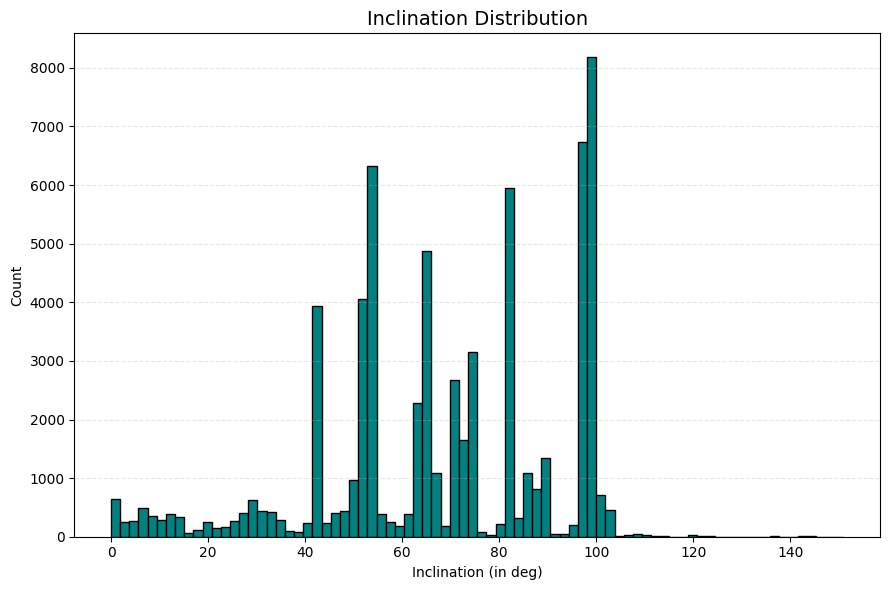

In [43]:
plt.figure(figsize=(9,6))
plt.hist(
    df['INCLINATION'].dropna(),
    bins=80,
    color="teal",
    edgecolor="black",
    alpha=0.99
)

plt.xlabel("Inclination (in deg)")
plt.ylabel("Count")
plt.title("Inclination Distribution", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

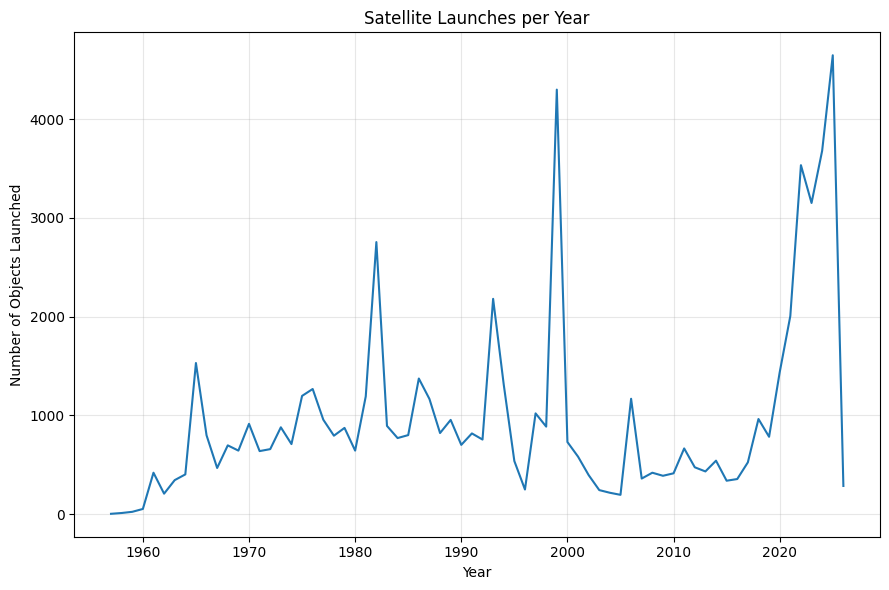

In [54]:
import matplotlib.pyplot as plt

# Drop missing values just to be safe
launch_years = df['LAUNCH_YEAR'].dropna().astype(int)

# Count launches per year
counts = launch_years.value_counts().sort_index()

plt.figure(figsize=(9, 6))
plt.plot(counts.index, counts.values, linewidth=1.5)

plt.title("Satellite Launches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Objects Launched")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert launch year
df['LAUNCH_YEAR'] = pd.to_numeric(df['LAUNCH_YEAR'], errors='coerce')
df_clean = df.dropna(subset=['LAUNCH_YEAR'])
df_clean['LAUNCH_YEAR'] = df_clean['LAUNCH_YEAR'].astype(int)

# Count launches per year
launch_counts = df_clean['LAUNCH_YEAR'].value_counts().sort_index()

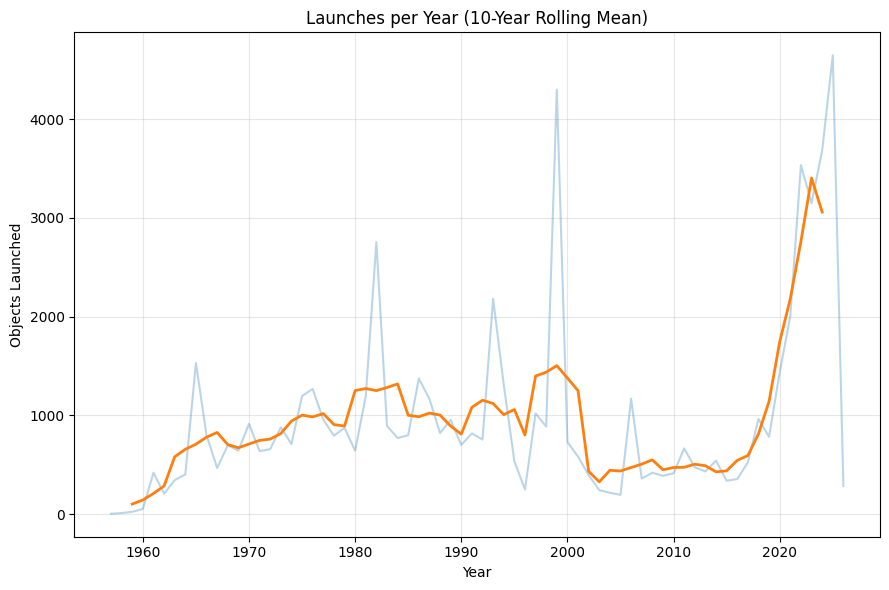

In [49]:
rolling = launch_counts.rolling(window=5, center=True).mean()

plt.figure(figsize=(9,6))
plt.plot(launch_counts.index, launch_counts.values, alpha=0.3)
plt.plot(rolling.index, rolling.values, linewidth=2)

plt.title("Launches per Year (10-Year Rolling Mean)")
plt.xlabel("Year")
plt.ylabel("Objects Launched")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

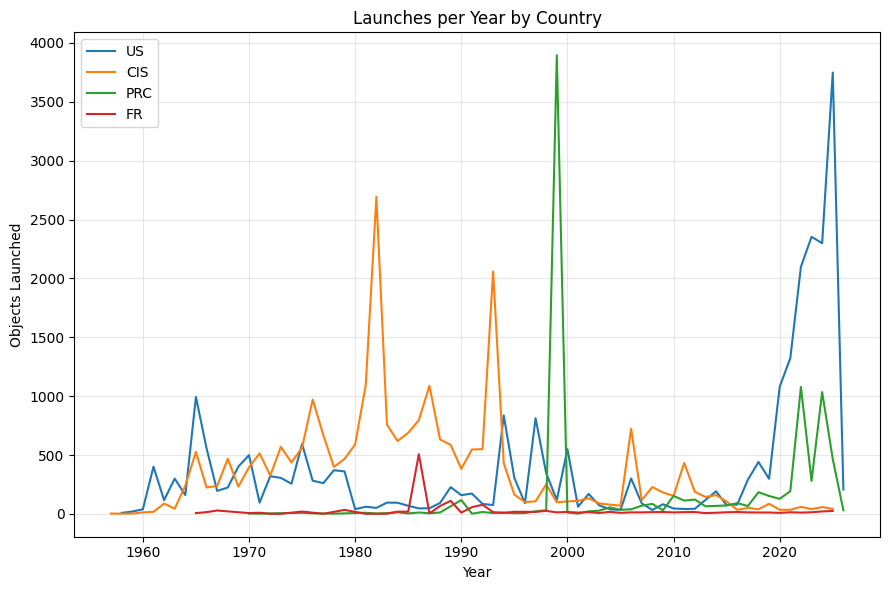

In [53]:
top_countries = df_clean['COUNTRY'].value_counts().head(4).index
sub = df_clean[df_clean['COUNTRY'].isin(top_countries)]

plt.figure(figsize=(9,6))

for country in top_countries:
    temp = sub[sub['COUNTRY'] == country]['LAUNCH_YEAR'].value_counts().sort_index()
    plt.plot(temp.index, temp.values, label=country)

plt.title("Launches per Year by Country")
plt.xlabel("Year")
plt.ylabel("Objects Launched")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

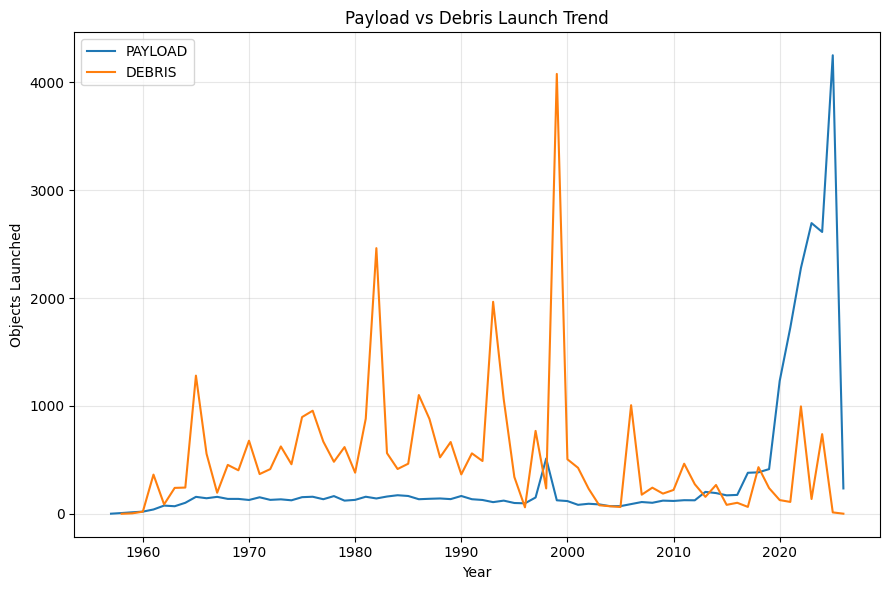

In [52]:
types = ['PAYLOAD', 'DEBRIS']
plt.figure(figsize=(9,6))

for t in types:
    temp = df_clean[df_clean['OBJECT_TYPE'] == t]['LAUNCH_YEAR'].value_counts().sort_index()
    plt.plot(temp.index, temp.values, label=t)

plt.title("Payload vs Debris Launch Trend")
plt.xlabel("Year")
plt.ylabel("Objects Launched")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

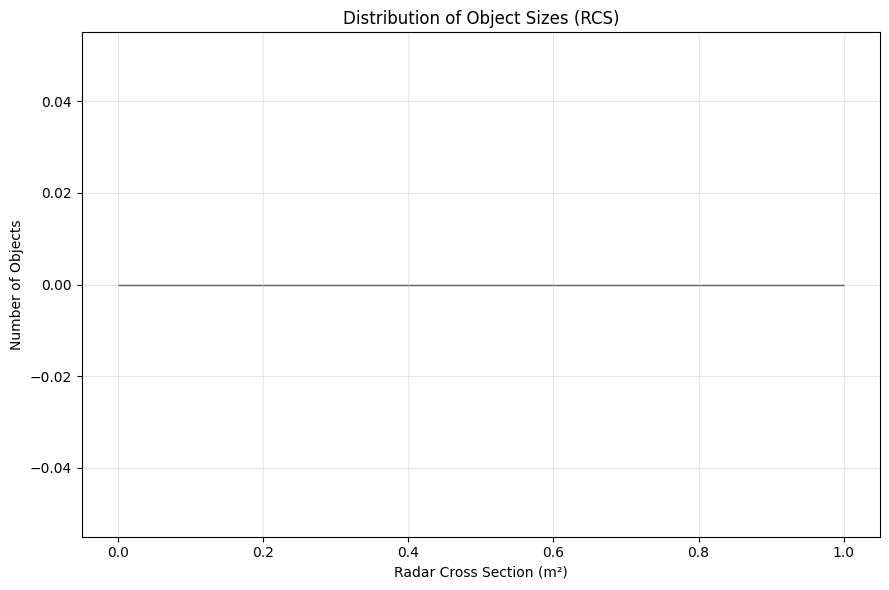

In [64]:
import matplotlib.pyplot as plt

# Clean numeric values
df_clean['RCS_SIZE'] = pd.to_numeric(df_clean['RCS_SIZE'], errors='coerce')
rcs = df_clean['RCS_SIZE'].dropna()

plt.figure(figsize=(9,6))
plt.hist(rcs, bins=50, color='gray', edgecolor='black', alpha=0.75)
plt.xlabel("Radar Cross Section (m²)")
plt.ylabel("Number of Objects")
plt.title("Distribution of Object Sizes (RCS)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

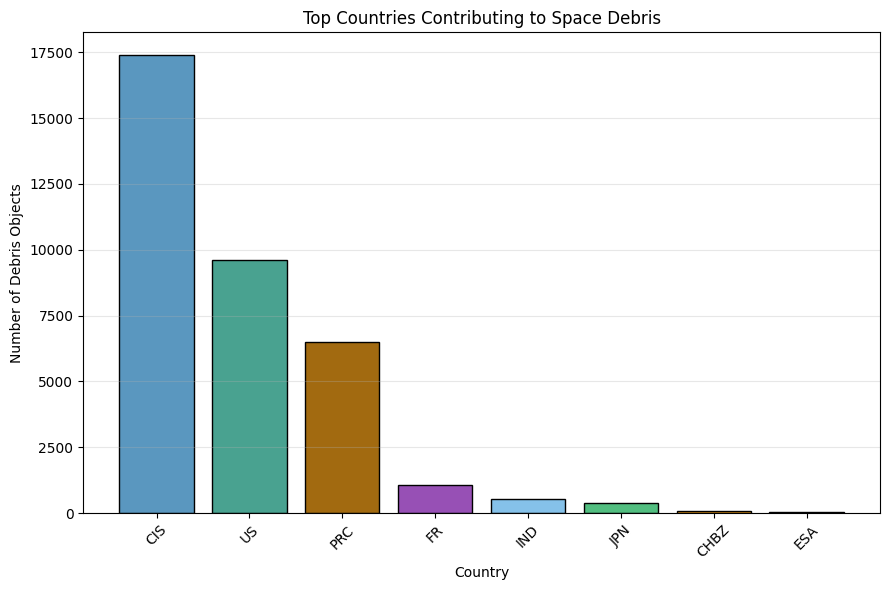

In [63]:
# Top 8 countries for clarity
top8_colors = ["#5A97BF", "#49A290", "#A26A10", "#9750B5", "#85C1E9", "#52BE80", "#F39C12", "#BB8FCE"]

plt.figure(figsize=(9,6))
plt.bar(debris_counts.index, debris_counts.values, color=top8_colors, edgecolor="black")
plt.xlabel("Country")
plt.ylabel("Number of Debris Objects")
plt.title("Top Countries Contributing to Space Debris")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()